In [1]:
# importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRFRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [2]:
# reading the dataset
carbon = pd.read_csv("carbon_snp_500.csv", index_col= "Date", parse_dates= True)

In [3]:
carbon.head()

,Domestic_Aviation,Ground_Transport,Industry,International_Aviation,Power,Residential,snp_500
Date,,,,,,,
2019-01-02,0.436517,4.94065,2.22424,0.190483,3.95599,3.47507,2510.030029
2019-01-03,0.469240,4.98876,2.53213,0.203517,4.50361,3.20613,2447.889893
2019-01-04,0.456743,5.00355,2.45294,0.203857,4.36275,2.92680,2531.939941
2019-01-07,0.421686,3.78389,1.87905,0.204479,3.34204,2.53096,2549.689941
2019-01-08,0.437056,4.70591,2.15024,0.198693,3.82438,2.22898,2574.409912


In [4]:
carbon.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1819 entries, 2019-01-02 to 2026-03-30
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Domestic_Aviation       1819 non-null   float64
 1   Ground_Transport        1819 non-null   float64
 2   Industry                1819 non-null   float64
 3   International_Aviation  1819 non-null   float64
 4   Power                   1819 non-null   float64
 5   Residential             1819 non-null   float64
 6   snp_500                 1819 non-null   float64
dtypes: float64(7)
memory usage: 113.7 KB


Correlation Analysis

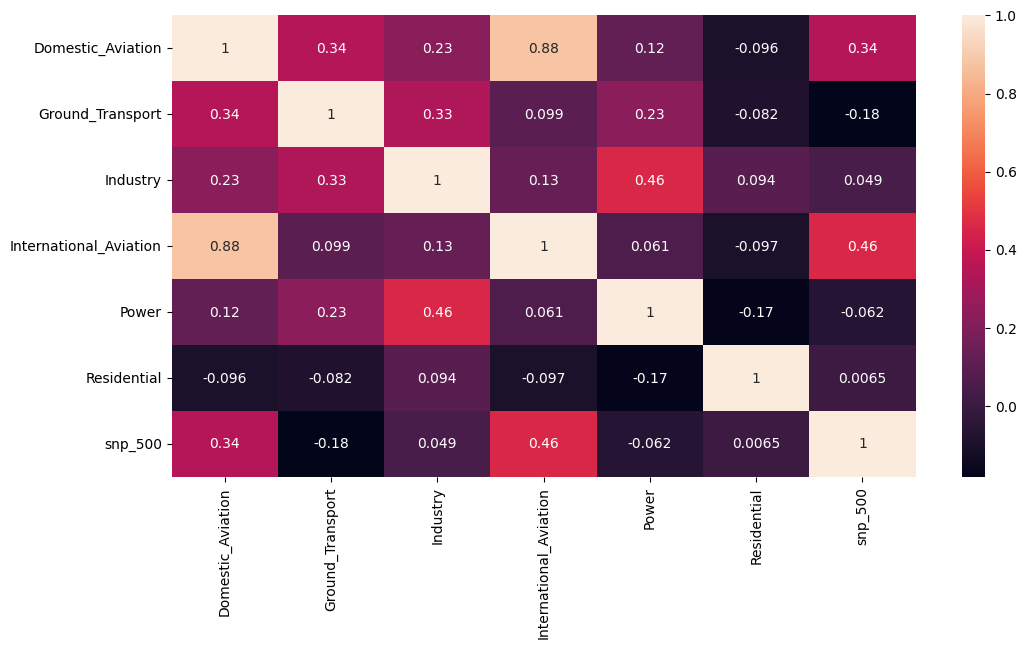

In [5]:
plt.figure(figsize=(12,6))
sns.heatmap(carbon.corr(), annot = True)
plt.show()

It seems that the domestic Aviation and International Aviation has 34% and 46% correlation with Snp 500

Transforming the dataset

In [6]:
df = carbon.copy()
for col in df.columns:
  df[f"{col}_ret"] = df[col].pct_change()
  df.drop(columns=[col], inplace = True)
df.dropna(inplace= True)
df.head()

,Domestic_Aviation_ret,Ground_Transport_ret,Industry_ret,International_Aviation_ret,Power_ret,Residential_ret,snp_500_ret
Date,,,,,,,
2019-01-03,0.074964,0.009738,0.138425,0.068426,0.138428,-0.077391,-0.024757
2019-01-04,-0.026632,0.002965,-0.031274,0.001671,-0.031277,-0.087124,0.034336
2019-01-07,-0.076754,-0.243759,-0.233960,0.003051,-0.233960,-0.135247,0.007010
2019-01-08,0.036449,0.243670,0.144323,-0.028296,0.144325,-0.119314,0.009695
2019-01-09,-0.032792,0.049882,-0.020393,-0.075196,-0.020390,0.262627,0.004098


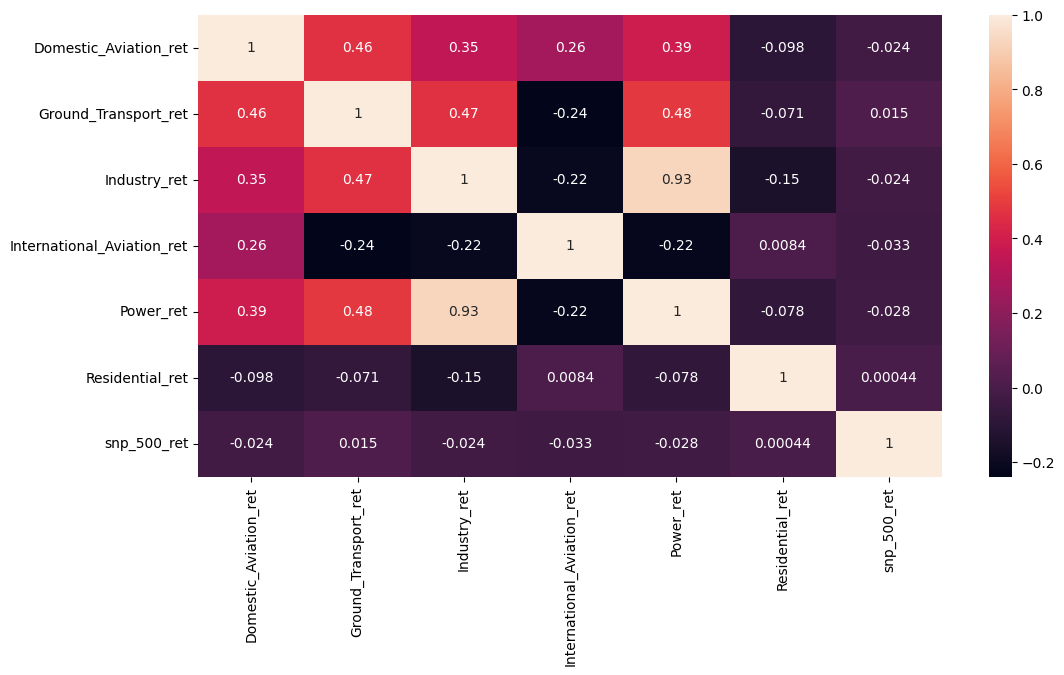

In [7]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), annot = True)
plt.show()

finding if there is any delayed predictive relationship in the dataset

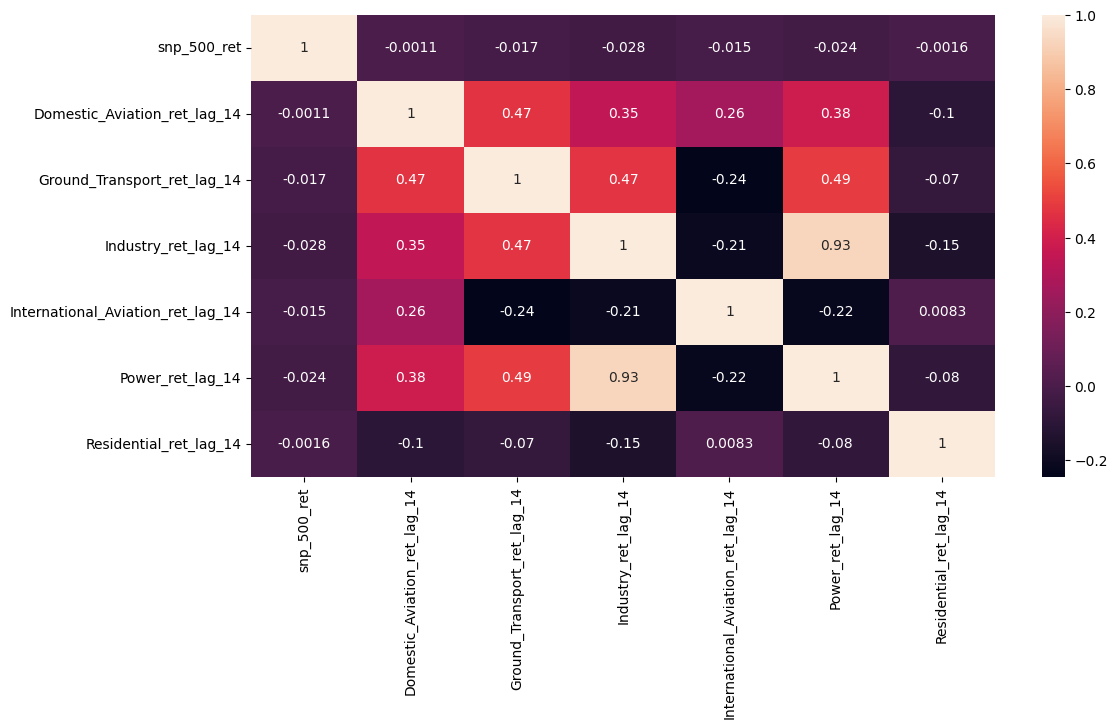

In [8]:
lag= 14
df_lag = df.copy()
for col in df_lag.columns:
  if col != "snp_500_ret":
    df_lag[f"{col}_lag_{lag}"] = df_lag[col].shift(lag)
    df_lag.drop(columns=[col], inplace = True)
df_lag.dropna(inplace = True)
plt.figure(figsize=(12,6))
sns.heatmap(df_lag.corr(), annot = True)
plt.show()


since the correlation did not improves we can consider that there is no delayed predictive relationship in the dataset. Instead we can us the percent change datset

In [9]:
# selecting x and y
x = df.drop(columns= ["snp_500_ret"])
y = df["snp_500_ret"]

In [10]:
# spliting the dataset into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, shuffle= False)

In [11]:
# scaling x_train and x_test
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [12]:
# building the models
lr = LinearRegression()
rf = RandomForestRegressor()
dt = DecisionTreeRegressor()
xgb = XGBRFRegressor()

In [13]:
# fitting data to the model
lr.fit(x_train_scaled, y_train)
rf.fit(x_train_scaled, y_train)
dt.fit(x_train_scaled, y_train)
xgb.fit(x_train_scaled, y_train)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=None, ...)

Measuring Accuracy

In [14]:
models = {"linear Regression" : lr, "Random Forest": rf, "Decision Tree": dt, "XGBoost": xgb}

results = []

for model_name, model in models.items():
  y_pred = model.predict(x_test_scaled)

  results.append([
      model_name,
      mean_absolute_error(y_test, y_pred),
      mean_squared_error(y_test, y_pred),
      np.sqrt(mean_squared_error(y_test, y_pred)),
      r2_score(y_test, y_pred)
  ])

result_df = pd.DataFrame(results, columns= ["Model", "MAE", "MSE", "RMSE", "R2 Score"])
result_df

,Model,MAE,MSE,RMSE,R2 Score
0,linear Regression,0.006898,0.000116,0.010792,0.001115
1,Random Forest,0.007237,0.000121,0.010983,-0.034568
2,Decision Tree,0.011537,0.000274,0.016567,-1.353954
3,XGBoost,0.007019,0.000118,0.010858,-0.011076


This project investigated whether sectoral CO2 emissions data could help explain or predict Snp 500 returns. After transforming the data into percentage changes to remove trend-driven relationships, the analysis showed weak correlations between emissions variables and daily market returns. Multiple machine learning models, including Linear Regression, Random Forest, Decision Tree, and XGBoost, were evaluated, but all produced negative R² scores, indicating limited predictive power for short-term market movements.  Overall, the findings suggest that sectoral CO₂ emissions may reflect broader economic activity but are not strong standalone predictors of daily S&P 500 returns.
